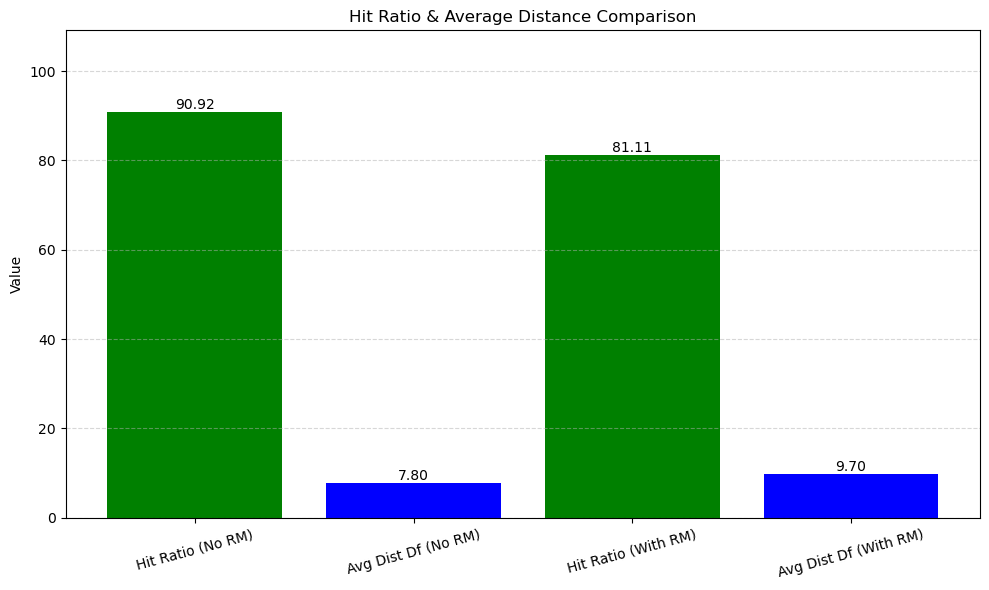

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 이름
files = {
    "No RM": "true_hit_ratio_no_RM.csv",
    "With RM": "true_hit_ratio_w_RM.csv"
}

# 결과 저장용 리스트
labels = []
hit_ratios = []
avg_dists = []

# 파일별 처리
for label, file in files.items():
    df = pd.read_csv(file)
    hit_ratio = df['is_hit'].mean() * 100
    avg_dist = df['dist_df'].mean()

    labels.append(f"Hit Ratio ({label})")
    hit_ratios.append(hit_ratio)

    labels.append(f"Avg Dist Df ({label})")
    avg_dists.append(avg_dist)

# 전체 막대그래프 그리기
values = []
colors = []

for i in range(len(labels)):
    if 'Hit Ratio' in labels[i]:
        values.append(hit_ratios[i // 2])
        colors.append('green')
    else:
        values.append(avg_dists[i // 2])
        colors.append('blue')

# 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)

# 값 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

plt.title('Hit Ratio & Average Distance Comparison')
plt.ylabel('Value')
plt.ylim(0, max(values) * 1.2)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

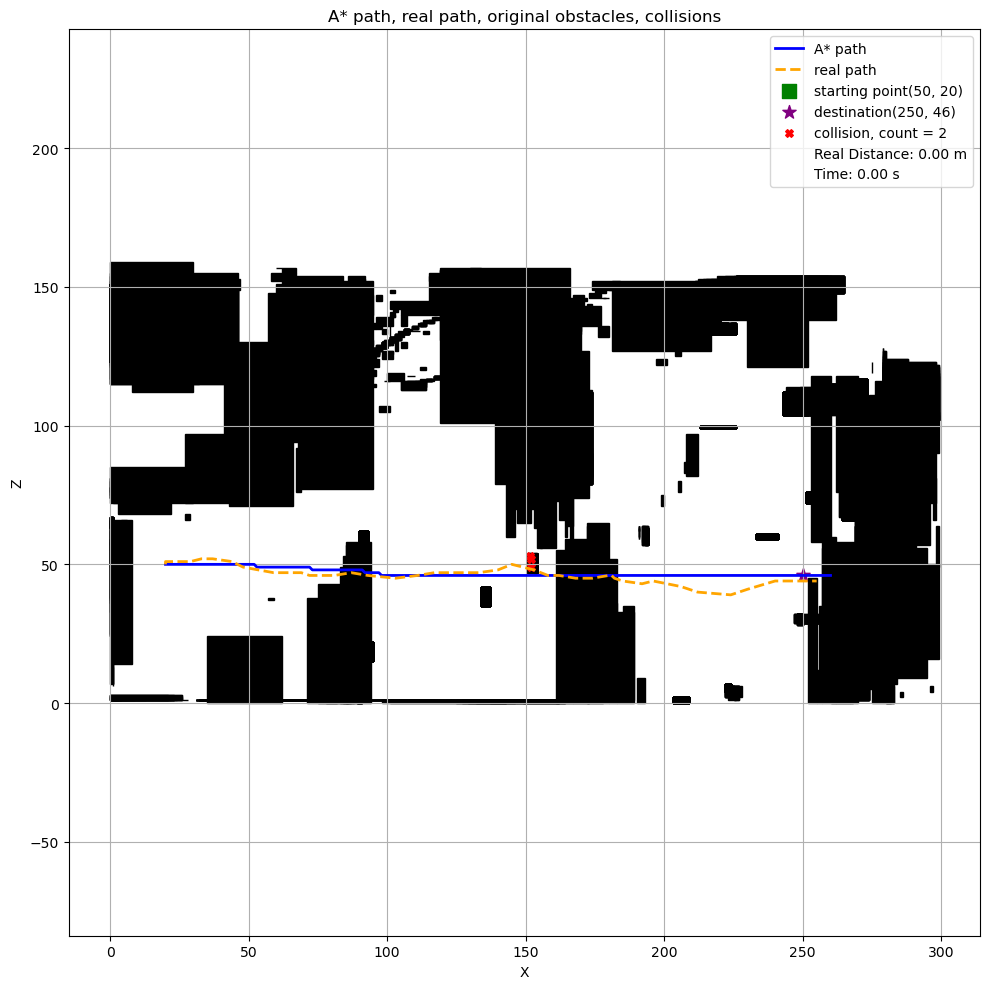

In [4]:
# 실제 obstacle의 크기 적용
# collision한 부분 그림에 표시 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# --- 설정 ---
GRID_SIZE = 300
maze = np.load("maze.npy")  # A* 계산용 장애물 맵 (buffer 포함)
a_star_df = pd.read_csv("a_star_path.csv")  # A* 경로
real_df = pd.read_csv("tank_path0.csv")     # 실제 이동 경로
start = (50, 20)
destination = (250, 46)

# --- 이동 정보 불러오기 ---
try:
    with open("move_info.json", "r") as f:
        move_info = json.load(f)
        real_distance = move_info.get("distance", 0.0)
        elapsed_time = move_info.get("elapsed_time", 0.0)
except FileNotFoundError:
    real_distance = 0.0
    elapsed_time = 0.0

# --- optional: 원래 장애물 좌표 json 또는 코드에 하드코딩해서 불러오기 ---
with open("original_obstacles.json", "r") as f:
    original_obstacles = json.load(f)

# --- collision 좌표 불러오기 ---
with open('collision_points.json', 'r') as col:
    collision_data = json.load(col)
    collision_points = collision_data.get("collision_points", [])
    count = collision_data.get("collision_count", [])

# --- 그래프 초기화 ---
plt.figure(figsize=(10, 10))
plt.title("A* path, real path, original obstacles, collisions")

# --- A* 경로 시각화 ---
plt.plot(a_star_df["x"], a_star_df["z"], color='blue', linewidth=2, label='A* path')

# --- 실제 경로 시각화 ---
plt.plot(real_df["x"], real_df["z"], color='orange', linestyle='--', linewidth=2, label='real path')

# --- 시작점, 목적지 표시 ---
plt.scatter([start[0]], [start[1]], c='green', s=100, marker='s', label=f'starting point{start}')
plt.scatter([destination[0]], [destination[1]], c='purple', s=100, marker='*', label=f'destination{destination}')

# --- 원래 장애물 표시 (buffer 제외) ---
for obs in original_obstacles:
    rect = plt.Rectangle((obs["x_min"], obs["z_min"]),
                         obs["x_max"] - obs["x_min"],
                         obs["z_max"] - obs["z_min"],
                         color="black")
    plt.gca().add_patch(rect)

# collision 좌표 찍기 (만약 collision_points가 비어있지 않으면)
if collision_points:
    cx, cz = zip(*collision_points)
    plt.scatter(cx, cz, c='red', s=30, marker='X', label=f'collision, count = {count}')

# ========================================================================================

plt.plot([], [], ' ', label=f"Real Distance: {real_distance:.2f} m")
plt.plot([], [], ' ', label=f"Time: {elapsed_time:.2f} s")

# ========================================================================================


# --- 최종 설정 ---
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.savefig("tank_result.png", dpi=300)
plt.show()

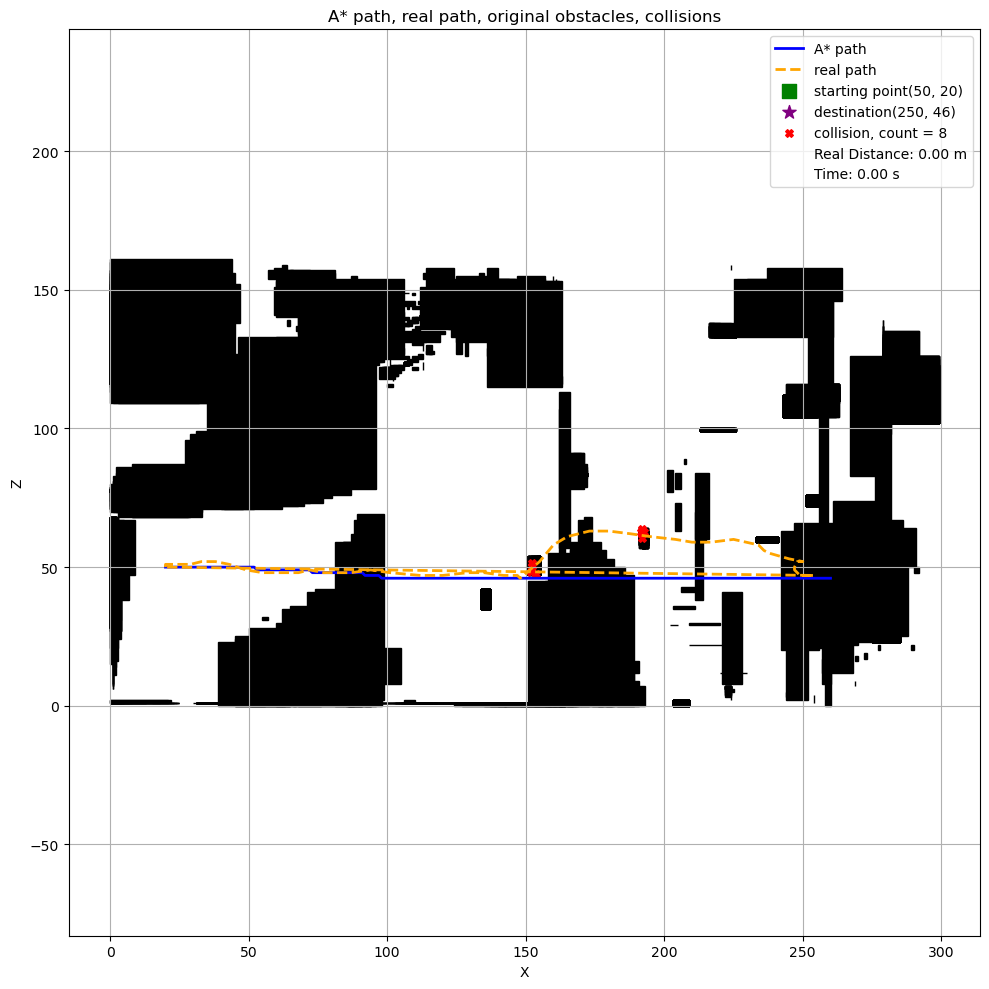

In [3]:
# 실제 obstacle의 크기 적용
# collision한 부분 그림에 표시 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# --- 설정 ---
GRID_SIZE = 300
maze = np.load("maze.npy")  # A* 계산용 장애물 맵 (buffer 포함)
a_star_df = pd.read_csv("a_star_path.csv")  # A* 경로
real_df = pd.read_csv("tank_path0.csv")     # 실제 이동 경로
start = (50, 20)
destination = (250, 46)

# --- 이동 정보 불러오기 ---
try:
    with open("move_info.json", "r") as f:
        move_info = json.load(f)
        real_distance = move_info.get("distance", 0.0)
        elapsed_time = move_info.get("elapsed_time", 0.0)
except FileNotFoundError:
    real_distance = 0.0
    elapsed_time = 0.0

# --- optional: 원래 장애물 좌표 json 또는 코드에 하드코딩해서 불러오기 ---
with open("original_obstacles.json", "r") as f:
    original_obstacles = json.load(f)

# --- collision 좌표 불러오기 ---
with open('collision_points.json', 'r') as col:
    collision_data = json.load(col)
    collision_points = collision_data.get("collision_points", [])
    count = collision_data.get("collision_count", [])

# --- 그래프 초기화 ---
plt.figure(figsize=(10, 10))
plt.title("A* path, real path, original obstacles, collisions")

# --- A* 경로 시각화 ---
plt.plot(a_star_df["x"], a_star_df["z"], color='blue', linewidth=2, label='A* path')

# --- 실제 경로 시각화 ---
plt.plot(real_df["x"], real_df["z"], color='orange', linestyle='--', linewidth=2, label='real path')

# --- 시작점, 목적지 표시 ---
plt.scatter([start[0]], [start[1]], c='green', s=100, marker='s', label=f'starting point{start}')
plt.scatter([destination[0]], [destination[1]], c='purple', s=100, marker='*', label=f'destination{destination}')

# --- 원래 장애물 표시 (buffer 제외) ---
for obs in original_obstacles:
    rect = plt.Rectangle((obs["x_min"], obs["z_min"]),
                         obs["x_max"] - obs["x_min"],
                         obs["z_max"] - obs["z_min"],
                         color="black")
    plt.gca().add_patch(rect)

# collision 좌표 찍기 (만약 collision_points가 비어있지 않으면)
if collision_points:
    cx, cz = zip(*collision_points)
    plt.scatter(cx, cz, c='red', s=30, marker='X', label=f'collision, count = {count}')

# ========================================================================================

plt.plot([], [], ' ', label=f"Real Distance: {real_distance:.2f} m")
plt.plot([], [], ' ', label=f"Time: {elapsed_time:.2f} s")

# ========================================================================================


# --- 최종 설정 ---
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.savefig("tank_result.png", dpi=300)
plt.show()

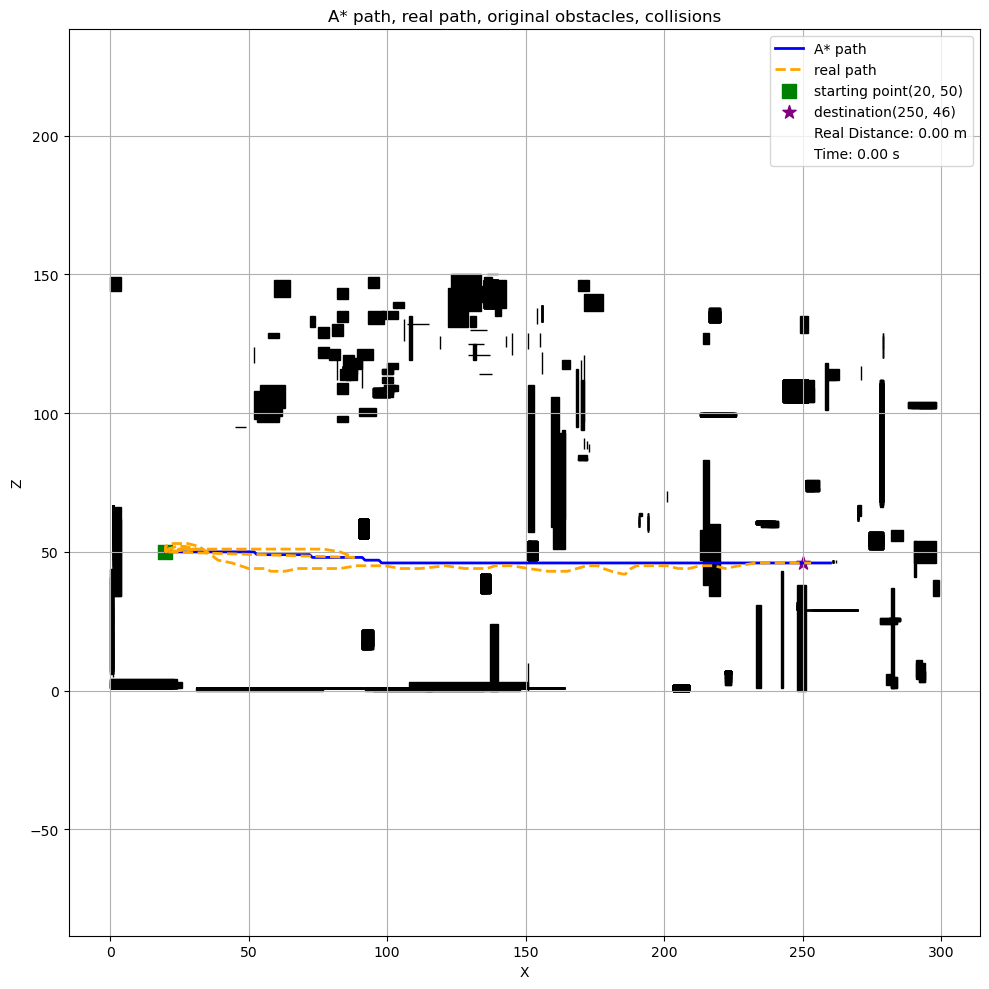

In [9]:
# 실제 obstacle의 크기 적용
# collision한 부분 그림에 표시 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# --- 설정 ---
GRID_SIZE = 300
maze = np.load("maze.npy")  # A* 계산용 장애물 맵 (buffer 포함)
a_star_df = pd.read_csv("a_star_path.csv")  # A* 경로
real_df = pd.read_csv("tank_path0.csv")     # 실제 이동 경로
start = (20, 50)
destination = (250, 46)

# --- 이동 정보 불러오기 ---
try:
    with open("move_info.json", "r") as f:
        move_info = json.load(f)
        real_distance = move_info.get("distance", 0.0)
        elapsed_time = move_info.get("elapsed_time", 0.0)
except FileNotFoundError:
    real_distance = 0.0
    elapsed_time = 0.0

# --- optional: 원래 장애물 좌표 json 또는 코드에 하드코딩해서 불러오기 ---
with open("original_obstacles.json", "r") as f:
    original_obstacles = json.load(f)

# --- collision 좌표 불러오기 ---
with open('collision_points.json', 'r') as col:
    collision_data = json.load(col)
    collision_points = collision_data.get("collision_points", [])
    count = collision_data.get("collision_count", [])

# --- 그래프 초기화 ---
plt.figure(figsize=(10, 10))
plt.title("A* path, real path, original obstacles, collisions")

# --- A* 경로 시각화 ---
plt.plot(a_star_df["x"], a_star_df["z"], color='blue', linewidth=2, label='A* path')

# --- 실제 경로 시각화 ---
plt.plot(real_df["x"], real_df["z"], color='orange', linestyle='--', linewidth=2, label='real path')

# --- 시작점, 목적지 표시 ---
plt.scatter([start[0]], [start[1]], c='green', s=100, marker='s', label=f'starting point{start}')
plt.scatter([destination[0]], [destination[1]], c='purple', s=100, marker='*', label=f'destination{destination}')

# --- 원래 장애물 표시 (buffer 제외) ---
for obs in original_obstacles:
    rect = plt.Rectangle((obs["x_min"], obs["z_min"]),
                         obs["x_max"] - obs["x_min"],
                         obs["z_max"] - obs["z_min"],
                         color="black")
    plt.gca().add_patch(rect)

# collision 좌표 찍기 (만약 collision_points가 비어있지 않으면)
if collision_points:
    cx, cz = zip(*collision_points)
    plt.scatter(cx, cz, c='red', s=30, marker='X', label=f'collision, count = {count}')

# ========================================================================================

plt.plot([], [], ' ', label=f"Real Distance: {real_distance:.2f} m")
plt.plot([], [], ' ', label=f"Time: {elapsed_time:.2f} s")

# ========================================================================================


# --- 최종 설정 ---
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.savefig("tank_result.png", dpi=300)
plt.show()

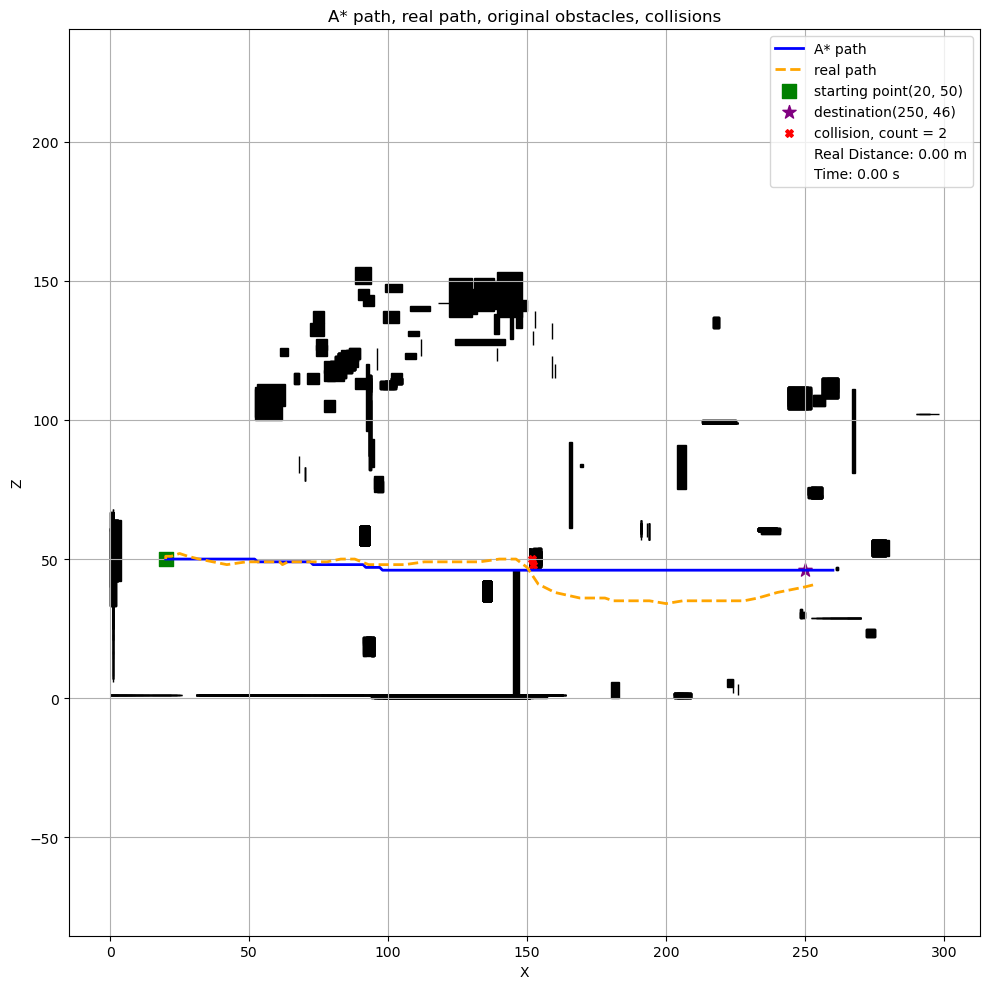

In [10]:
# 실제 obstacle의 크기 적용
# collision한 부분 그림에 표시 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# --- 설정 ---
GRID_SIZE = 300
maze = np.load("maze.npy")  # A* 계산용 장애물 맵 (buffer 포함)
a_star_df = pd.read_csv("a_star_path.csv")  # A* 경로
real_df = pd.read_csv("tank_path0.csv")     # 실제 이동 경로
start = (20, 50)
destination = (250, 46)

# --- 이동 정보 불러오기 ---
try:
    with open("move_info.json", "r") as f:
        move_info = json.load(f)
        real_distance = move_info.get("distance", 0.0)
        elapsed_time = move_info.get("elapsed_time", 0.0)
except FileNotFoundError:
    real_distance = 0.0
    elapsed_time = 0.0

# --- optional: 원래 장애물 좌표 json 또는 코드에 하드코딩해서 불러오기 ---
with open("original_obstacles.json", "r") as f:
    original_obstacles = json.load(f)

# --- collision 좌표 불러오기 ---
with open('collision_points.json', 'r') as col:
    collision_data = json.load(col)
    collision_points = collision_data.get("collision_points", [])
    count = collision_data.get("collision_count", [])

# --- 그래프 초기화 ---
plt.figure(figsize=(10, 10))
plt.title("A* path, real path, original obstacles, collisions")

# --- A* 경로 시각화 ---
plt.plot(a_star_df["x"], a_star_df["z"], color='blue', linewidth=2, label='A* path')

# --- 실제 경로 시각화 ---
plt.plot(real_df["x"], real_df["z"], color='orange', linestyle='--', linewidth=2, label='real path')

# --- 시작점, 목적지 표시 ---
plt.scatter([start[0]], [start[1]], c='green', s=100, marker='s', label=f'starting point{start}')
plt.scatter([destination[0]], [destination[1]], c='purple', s=100, marker='*', label=f'destination{destination}')

# --- 원래 장애물 표시 (buffer 제외) ---
for obs in original_obstacles:
    rect = plt.Rectangle((obs["x_min"], obs["z_min"]),
                         obs["x_max"] - obs["x_min"],
                         obs["z_max"] - obs["z_min"],
                         color="black")
    plt.gca().add_patch(rect)

# collision 좌표 찍기 (만약 collision_points가 비어있지 않으면)
if collision_points:
    cx, cz = zip(*collision_points)
    plt.scatter(cx, cz, c='red', s=30, marker='X', label=f'collision, count = {count}')

# ========================================================================================

plt.plot([], [], ' ', label=f"Real Distance: {real_distance:.2f} m")
plt.plot([], [], ' ', label=f"Time: {elapsed_time:.2f} s")

# ========================================================================================


# --- 최종 설정 ---
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.savefig("tank_result.png", dpi=300)
plt.show()

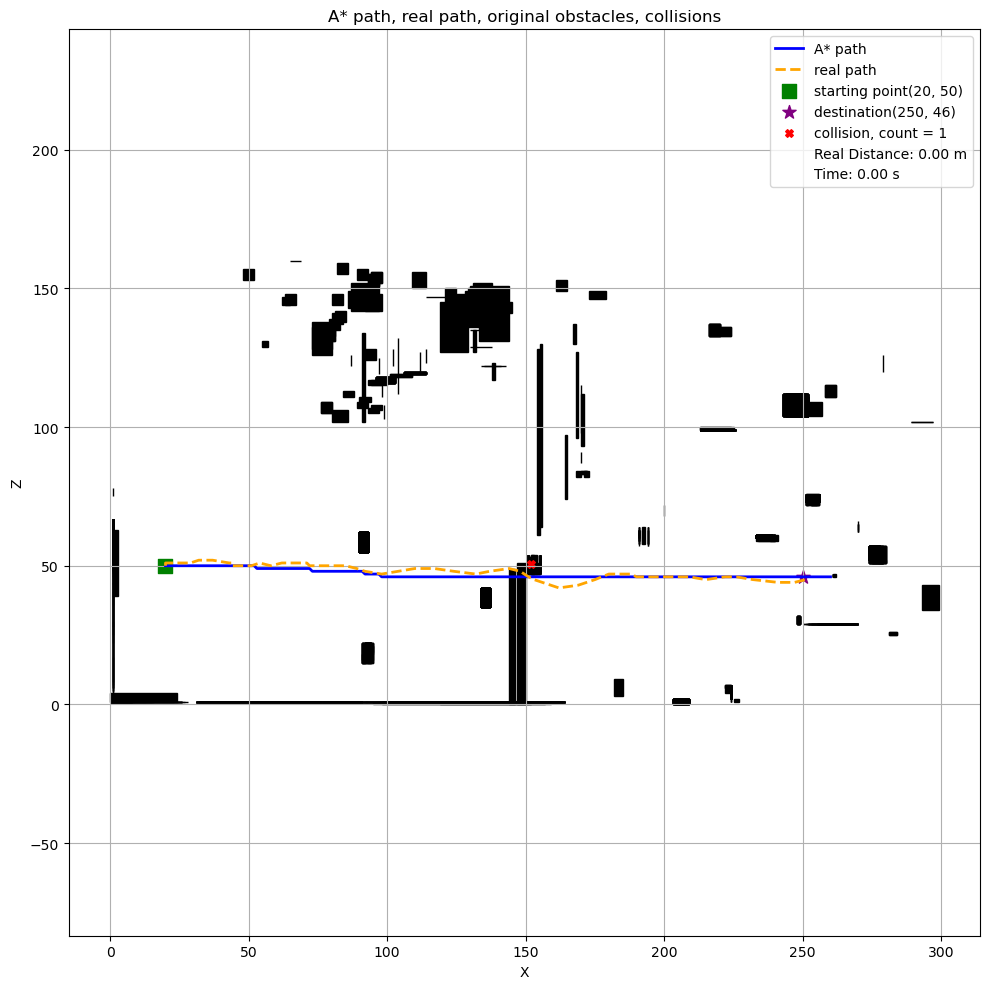

In [12]:
# 실제 obstacle의 크기 적용
# collision한 부분 그림에 표시 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# --- 설정 ---
GRID_SIZE = 300
maze = np.load("maze.npy")  # A* 계산용 장애물 맵 (buffer 포함)
a_star_df = pd.read_csv("a_star_path.csv")  # A* 경로
real_df = pd.read_csv("tank_path0.csv")     # 실제 이동 경로
start = (20, 50)
destination = (250, 46)

# --- 이동 정보 불러오기 ---
try:
    with open("move_info.json", "r") as f:
        move_info = json.load(f)
        real_distance = move_info.get("distance", 0.0)
        elapsed_time = move_info.get("elapsed_time", 0.0)
except FileNotFoundError:
    real_distance = 0.0
    elapsed_time = 0.0

# --- optional: 원래 장애물 좌표 json 또는 코드에 하드코딩해서 불러오기 ---
with open("original_obstacles.json", "r") as f:
    original_obstacles = json.load(f)

# --- collision 좌표 불러오기 ---
with open('collision_points.json', 'r') as col:
    collision_data = json.load(col)
    collision_points = collision_data.get("collision_points", [])
    count = collision_data.get("collision_count", [])

# --- 그래프 초기화 ---
plt.figure(figsize=(10, 10))
plt.title("A* path, real path, original obstacles, collisions")

# --- A* 경로 시각화 ---
plt.plot(a_star_df["x"], a_star_df["z"], color='blue', linewidth=2, label='A* path')

# --- 실제 경로 시각화 ---
plt.plot(real_df["x"], real_df["z"], color='orange', linestyle='--', linewidth=2, label='real path')

# --- 시작점, 목적지 표시 ---
plt.scatter([start[0]], [start[1]], c='green', s=100, marker='s', label=f'starting point{start}')
plt.scatter([destination[0]], [destination[1]], c='purple', s=100, marker='*', label=f'destination{destination}')

# --- 원래 장애물 표시 (buffer 제외) ---
for obs in original_obstacles:
    rect = plt.Rectangle((obs["x_min"], obs["z_min"]),
                         obs["x_max"] - obs["x_min"],
                         obs["z_max"] - obs["z_min"],
                         color="black")
    plt.gca().add_patch(rect)

# collision 좌표 찍기 (만약 collision_points가 비어있지 않으면)
if collision_points:
    cx, cz = zip(*collision_points)
    plt.scatter(cx, cz, c='red', s=30, marker='X', label=f'collision, count = {count}')

# ========================================================================================

plt.plot([], [], ' ', label=f"Real Distance: {real_distance:.2f} m")
plt.plot([], [], ' ', label=f"Time: {elapsed_time:.2f} s")

# ========================================================================================


# --- 최종 설정 ---
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.savefig("tank_result.png", dpi=300)
plt.show()

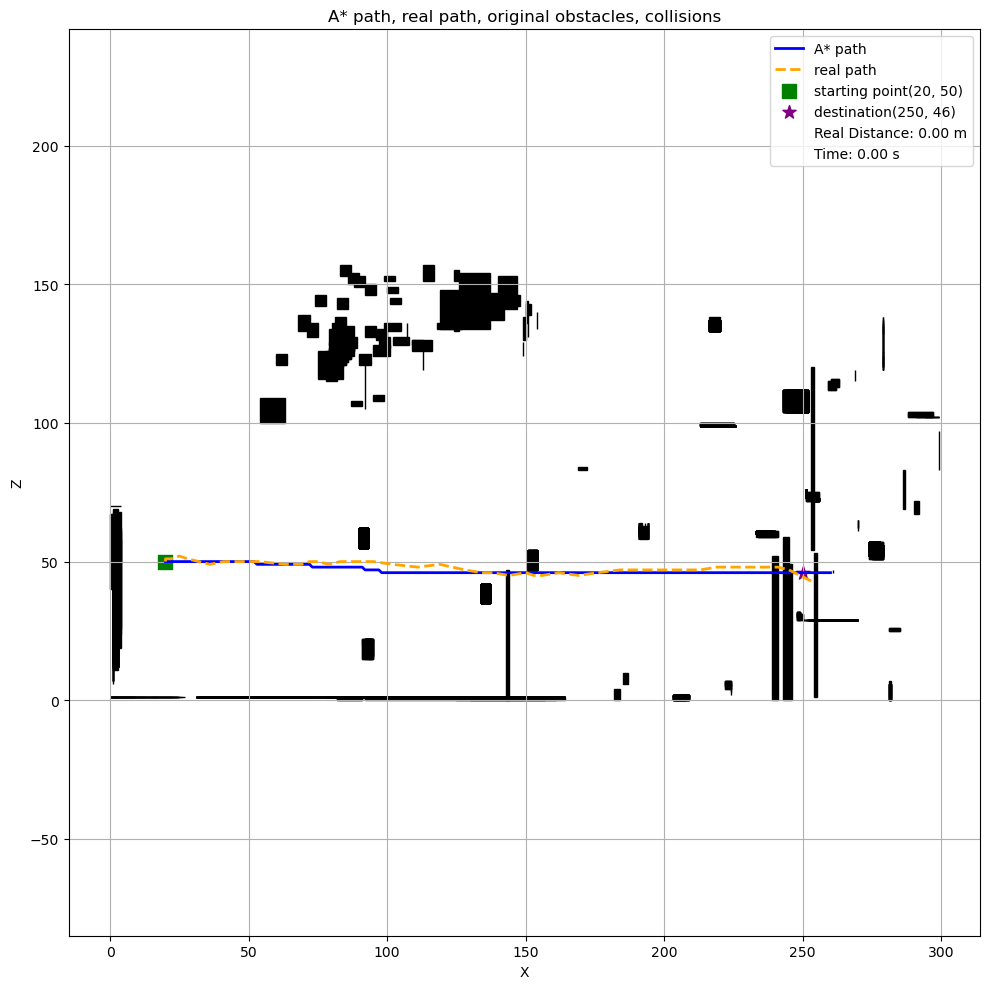

In [11]:
# 실제 obstacle의 크기 적용
# collision한 부분 그림에 표시 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# --- 설정 ---
GRID_SIZE = 300
maze = np.load("maze.npy")  # A* 계산용 장애물 맵 (buffer 포함)
a_star_df = pd.read_csv("a_star_path.csv")  # A* 경로
real_df = pd.read_csv("tank_path0.csv")     # 실제 이동 경로
start = (20, 50)
destination = (250, 46)

# --- 이동 정보 불러오기 ---
try:
    with open("move_info.json", "r") as f:
        move_info = json.load(f)
        real_distance = move_info.get("distance", 0.0)
        elapsed_time = move_info.get("elapsed_time", 0.0)
except FileNotFoundError:
    real_distance = 0.0
    elapsed_time = 0.0

# --- optional: 원래 장애물 좌표 json 또는 코드에 하드코딩해서 불러오기 ---
with open("original_obstacles.json", "r") as f:
    original_obstacles = json.load(f)

# --- collision 좌표 불러오기 ---
with open('collision_points.json', 'r') as col:
    collision_data = json.load(col)
    collision_points = collision_data.get("collision_points", [])
    count = collision_data.get("collision_count", [])

# --- 그래프 초기화 ---
plt.figure(figsize=(10, 10))
plt.title("A* path, real path, original obstacles, collisions")

# --- A* 경로 시각화 ---
plt.plot(a_star_df["x"], a_star_df["z"], color='blue', linewidth=2, label='A* path')

# --- 실제 경로 시각화 ---
plt.plot(real_df["x"], real_df["z"], color='orange', linestyle='--', linewidth=2, label='real path')

# --- 시작점, 목적지 표시 ---
plt.scatter([start[0]], [start[1]], c='green', s=100, marker='s', label=f'starting point{start}')
plt.scatter([destination[0]], [destination[1]], c='purple', s=100, marker='*', label=f'destination{destination}')

# --- 원래 장애물 표시 (buffer 제외) ---
for obs in original_obstacles:
    rect = plt.Rectangle((obs["x_min"], obs["z_min"]),
                         obs["x_max"] - obs["x_min"],
                         obs["z_max"] - obs["z_min"],
                         color="black")
    plt.gca().add_patch(rect)

# collision 좌표 찍기 (만약 collision_points가 비어있지 않으면)
if collision_points:
    cx, cz = zip(*collision_points)
    plt.scatter(cx, cz, c='red', s=30, marker='X', label=f'collision, count = {count}')

# ========================================================================================

plt.plot([], [], ' ', label=f"Real Distance: {real_distance:.2f} m")
plt.plot([], [], ' ', label=f"Time: {elapsed_time:.2f} s")

# ========================================================================================


# --- 최종 설정 ---
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.savefig("tank_result.png", dpi=300)
plt.show()

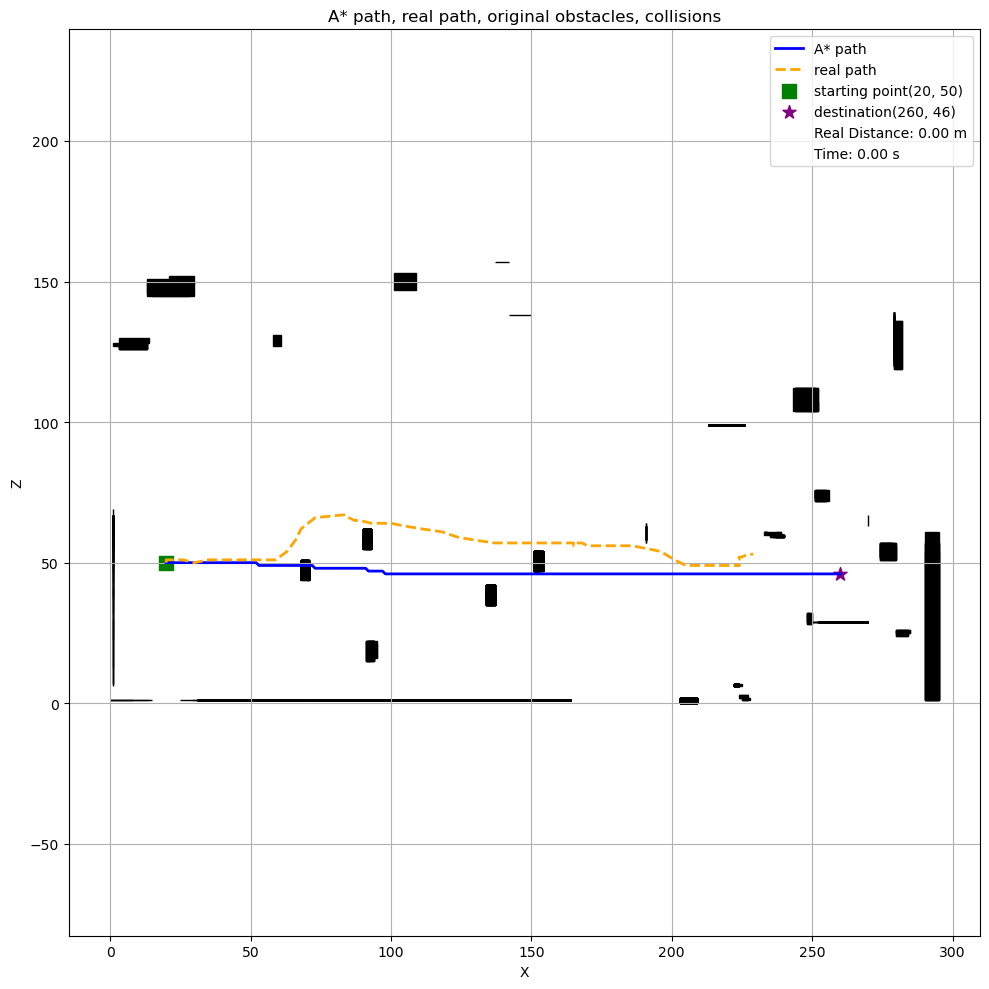

In [26]:
# 실제 obstacle의 크기 적용
# collision한 부분 그림에 표시 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# --- 설정 ---
GRID_SIZE = 300
maze = np.load("maze.npy")  # A* 계산용 장애물 맵 (buffer 포함)
a_star_df = pd.read_csv("a_star_path.csv")  # A* 경로
real_df = pd.read_csv("tank_path0.csv")     # 실제 이동 경로
start = (20, 50)
destination = (260, 46)

# --- 이동 정보 불러오기 ---
try:
    with open("move_info.json", "r") as f:
        move_info = json.load(f)
        real_distance = move_info.get("distance", 0.0)
        elapsed_time = move_info.get("elapsed_time", 0.0)
except FileNotFoundError:
    real_distance = 0.0
    elapsed_time = 0.0

# --- optional: 원래 장애물 좌표 json 또는 코드에 하드코딩해서 불러오기 ---
with open("original_obstacles.json", "r") as f:
    original_obstacles = json.load(f)

# --- collision 좌표 불러오기 ---
with open('collision_points.json', 'r') as col:
    collision_data = json.load(col)
    collision_points = collision_data.get("collision_points", [])
    count = collision_data.get("collision_count", [])

# --- 그래프 초기화 ---
plt.figure(figsize=(10, 10))
plt.title("A* path, real path, original obstacles, collisions")

# --- A* 경로 시각화 ---
plt.plot(a_star_df["x"], a_star_df["z"], color='blue', linewidth=2, label='A* path')

# --- 실제 경로 시각화 ---
plt.plot(real_df["x"], real_df["z"], color='orange', linestyle='--', linewidth=2, label='real path')

# --- 시작점, 목적지 표시 ---
plt.scatter([start[0]], [start[1]], c='green', s=100, marker='s', label=f'starting point{start}')
plt.scatter([destination[0]], [destination[1]], c='purple', s=100, marker='*', label=f'destination{destination}')

# --- 원래 장애물 표시 (buffer 제외) ---
for obs in original_obstacles:
    rect = plt.Rectangle((obs["x_min"], obs["z_min"]),
                         obs["x_max"] - obs["x_min"],
                         obs["z_max"] - obs["z_min"],
                         color="black")
    plt.gca().add_patch(rect)

# collision 좌표 찍기 (만약 collision_points가 비어있지 않으면)
if collision_points:
    cx, cz = zip(*collision_points)
    plt.scatter(cx, cz, c='red', s=30, marker='X', label=f'collision, count = {count}')

# ========================================================================================

plt.plot([], [], ' ', label=f"Real Distance: {real_distance:.2f} m")
plt.plot([], [], ' ', label=f"Time: {elapsed_time:.2f} s")

# ========================================================================================


# --- 최종 설정 ---
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.savefig("tank_result.png", dpi=300)
plt.show()

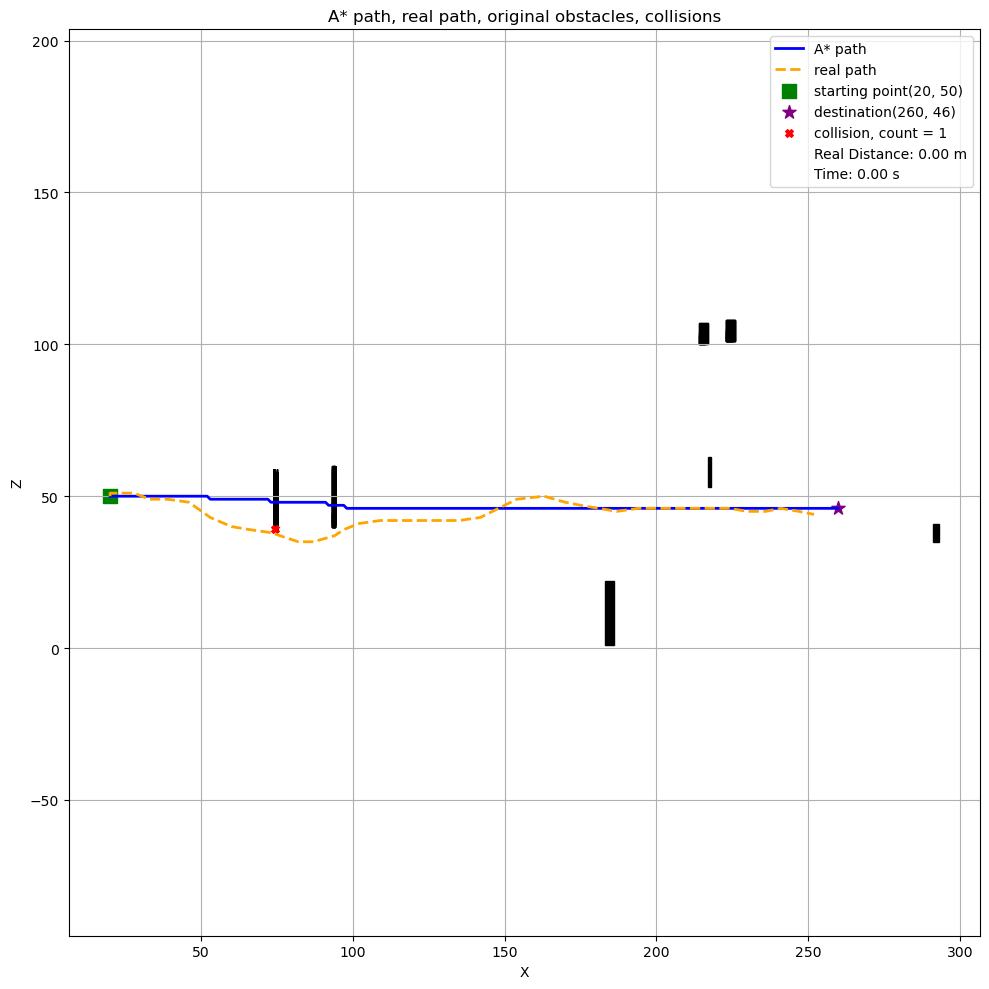

In [31]:
# 실제 obstacle의 크기 적용
# collision한 부분 그림에 표시 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# --- 설정 ---
GRID_SIZE = 300
maze = np.load("maze.npy")  # A* 계산용 장애물 맵 (buffer 포함)
a_star_df = pd.read_csv("a_star_path.csv")  # A* 경로
real_df = pd.read_csv("tank_path0.csv")     # 실제 이동 경로
start = (20, 50)
destination = (260, 46)

# --- 이동 정보 불러오기 ---
try:
    with open("move_info.json", "r") as f:
        move_info = json.load(f)
        real_distance = move_info.get("distance", 0.0)
        elapsed_time = move_info.get("elapsed_time", 0.0)
except FileNotFoundError:
    real_distance = 0.0
    elapsed_time = 0.0

# --- optional: 원래 장애물 좌표 json 또는 코드에 하드코딩해서 불러오기 ---
with open("original_obstacles.json", "r") as f:
    original_obstacles = json.load(f)

# --- collision 좌표 불러오기 ---
with open('collision_points.json', 'r') as col:
    collision_data = json.load(col)
    collision_points = collision_data.get("collision_points", [])
    count = collision_data.get("collision_count", [])

# --- 그래프 초기화 ---
plt.figure(figsize=(10, 10))
plt.title("A* path, real path, original obstacles, collisions")

# --- A* 경로 시각화 ---
plt.plot(a_star_df["x"], a_star_df["z"], color='blue', linewidth=2, label='A* path')

# --- 실제 경로 시각화 ---
plt.plot(real_df["x"], real_df["z"], color='orange', linestyle='--', linewidth=2, label='real path')

# --- 시작점, 목적지 표시 ---
plt.scatter([start[0]], [start[1]], c='green', s=100, marker='s', label=f'starting point{start}')
plt.scatter([destination[0]], [destination[1]], c='purple', s=100, marker='*', label=f'destination{destination}')

# --- 원래 장애물 표시 (buffer 제외) ---
for obs in original_obstacles:
    rect = plt.Rectangle((obs["x_min"], obs["z_min"]),
                         obs["x_max"] - obs["x_min"],
                         obs["z_max"] - obs["z_min"],
                         color="black")
    plt.gca().add_patch(rect)

# collision 좌표 찍기 (만약 collision_points가 비어있지 않으면)
if collision_points:
    cx, cz = zip(*collision_points)
    plt.scatter(cx, cz, c='red', s=30, marker='X', label=f'collision, count = {count}')

# ========================================================================================

plt.plot([], [], ' ', label=f"Real Distance: {real_distance:.2f} m")
plt.plot([], [], ' ', label=f"Time: {elapsed_time:.2f} s")

# ========================================================================================


# --- 최종 설정 ---
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.savefig("tank_result.png", dpi=300)
plt.show()